# TFM: Analisis y Prediccion de la Extorsion en Colombia
## Cuaderno Maestro Unificado

Este cuaderno consolida todo el proceso de analisis, desde la carga y limpieza de datos hasta el modelado predictivo y la visualizacion de resultados.

**Contenido:**
1. Configuracion Inicial
2. Carga de Datos Consolidados
3. Exploracion Inicial de Datos
4. Analisis de Series de Tiempo
5. Analisis de Distribucion de Variables
6. Analisis de Correlaciones
7. Seleccion de Variables
8. Division Temporal de Datos
9. Configuracion del Pipeline
10. Entrenamiento de Modelos
11. Comparacion de Modelos
12. Analisis del Mejor Modelo
13. Visualizacion Geografica
14. Conclusiones

---
## 1. Configuracion Inicial

In [1]:
# Librerias basicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time
from datetime import datetime

# Librerias de modelado
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_selection import RFECV
from xgboost import XGBRegressor
import joblib

# Librerias geograficas
import geopandas as gpd

# Configuracion de visualizacion
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
sns.set_palette('husl')

# Crear directorios de salida
OUTPUT_PATH = 'generated_data'
output_dir = f'{OUTPUT_PATH}/model_outputs'
os.makedirs(output_dir, exist_ok=True)
os.makedirs(OUTPUT_PATH, exist_ok=True)

# Contador de figuras para numeracion
fig_counter = 0

def save_figure(name, fig=None):
    """Guarda figura con numeracion automatica."""
    global fig_counter
    fig_counter += 1
    filename = f'{output_dir}/{fig_counter:02d}_{name}.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"Grafico guardado: {filename}")
    return filename

print("Librerias cargadas correctamente")
print(f"Directorio de salida: {output_dir}")

Librerias cargadas correctamente
Directorio de salida: generated_data/model_outputs


---
## 2. Carga de Datos Consolidados

In [2]:
print("="*80)
print("CARGA DE DATOS CONSOLIDADOS".center(80))
print("="*80)

# Cargar dataset consolidado
data_path = f'{OUTPUT_PATH}/consolidado_ultimos_10_anos.csv'
print(f"\nCargando datos desde: {data_path}")

datos = pd.read_csv(data_path)
print(f"Dataset cargado exitosamente")
print(f"Dimensiones: {datos.shape[0]:,} filas x {datos.shape[1]} columnas")

# Mostrar columnas disponibles
print(f"\nColumnas disponibles:")
print(datos.columns.tolist())

# Mostrar primeras filas
print("\nPrimeras 5 filas del dataset:")
display(datos.head())

                          CARGA DE DATOS CONSOLIDADOS                           

Cargando datos desde: generated_data/consolidado_ultimos_10_anos.csv
Dataset cargado exitosamente
Dimensiones: 7,235 filas x 18 columnas

Columnas disponibles:
['cod_dpto', 'dpto_nombre', 'cod_mun', 'mun_nombre', 'ano', 'total_extorsion', 'total_homicidios', 'total_hurtos', 'total_terrorismo', 'hectareas_coca', 'cobertura_2g', 'cobertura_3g', 'cobertura_4g', 'cobertura_lte', 'cobertura_5g', 'total_atentados', 'victimas_atentados', 'pib_total_miles_millones']

Primeras 5 filas del dataset:


,cod_dpto,dpto_nombre,cod_mun,mun_nombre,ano,total_extorsion,total_homicidios,total_hurtos,total_terrorismo,hectareas_coca,cobertura_2g,cobertura_3g,cobertura_4g,cobertura_lte,cobertura_5g,total_atentados,victimas_atentados,pib_total_miles_millones
0,5,ANTIOQUIA,5001,MEDELLIN,2016,336,530.0,13425.0,9.0,NaN,1.0,1.0,0.0,1.0,0.0,NaN,NaN,126021.66
1,5,ANTIOQUIA,5001,MEDELLIN,2017,488,572.0,17825.0,6.0,NaN,1.0,1.0,0.0,1.0,0.0,NaN,NaN,132368.59
2,5,ANTIOQUIA,5001,MEDELLIN,2018,578,625.0,21975.0,3.0,NaN,1.0,1.0,0.0,1.0,0.0,NaN,NaN,141680.06
3,5,ANTIOQUIA,5001,MEDELLIN,2019,648,576.0,27263.0,10.0,NaN,1.0,1.0,0.0,1.0,0.0,NaN,NaN,153559.42
4,5,ANTIOQUIA,5001,MEDELLIN,2020,634,366.0,17776.0,3.0,NaN,1.0,1.0,0.0,1.0,0.0,NaN,NaN,148361.90


In [3]:
# Definir mapeo de variables
# Variable objetivo
target = 'total_extorsion'

# Variables identificadoras (no usar en modelo)
id_vars = ['cod_dpto', 'dpto_nombre', 'cod_mun', 'mun_nombre']

# Variables temporales
time_var = 'ano'

# Variables predictoras potenciales
feature_vars = [
    'total_poblacion',
    'total_homicidios',
    'total_hurtos',
    'total_terrorismo',
    'hectareas_coca',
    'cobertura_2g',
    'cobertura_3g',
    'cobertura_4g',
    'cobertura_lte',
    'cobertura_5g',
    'total_atentados',
    'victimas_atentados',
    'pib_total_miles_millones'
]

# Filtrar solo variables que existen en el dataset
feature_vars = [f for f in feature_vars if f in datos.columns]
print(f"Variables predictoras disponibles ({len(feature_vars)}):")
for var in feature_vars:
    print(f"   - {var}")

Variables predictoras disponibles (12):
   - total_homicidios
   - total_hurtos
   - total_terrorismo
   - hectareas_coca
   - cobertura_2g
   - cobertura_3g
   - cobertura_4g
   - cobertura_lte
   - cobertura_5g
   - total_atentados
   - victimas_atentados
   - pib_total_miles_millones


---
## 3. Exploracion Inicial de Datos

In [4]:
print("="*80)
print("EXPLORACION INICIAL DE DATOS".center(80))
print("="*80)

print("\nINFORMACION GENERAL DEL DATASET")
print("-"*50)
print(f"Numero de filas: {datos.shape[0]:,}")
print(f"Numero de columnas: {datos.shape[1]}")

print("\nTIPOS DE DATOS")
print("-"*50)
print(datos.dtypes)

print("\nESTADISTICAS DESCRIPTIVAS")
print("-"*50)
display(datos.describe())

                          EXPLORACION INICIAL DE DATOS                          

INFORMACION GENERAL DEL DATASET
--------------------------------------------------
Numero de filas: 7,235
Numero de columnas: 18

TIPOS DE DATOS
--------------------------------------------------
cod_dpto                      int64
dpto_nombre                  object
cod_mun                       int64
mun_nombre                   object
ano                           int64
total_extorsion               int64
total_homicidios            float64
total_hurtos                float64
total_terrorismo            float64
hectareas_coca              float64
cobertura_2g                float64
cobertura_3g                float64
cobertura_4g                float64
cobertura_lte               float64
cobertura_5g                float64
total_atentados             float64
victimas_atentados          float64
pib_total_miles_millones    float64
dtype: object

ESTADISTICAS DESCRIPTIVAS
---------------------------------

,cod_dpto,cod_mun,ano,total_extorsion,total_homicidios,total_hurtos,total_terrorismo,hectareas_coca,cobertura_2g,cobertura_3g,cobertura_4g,cobertura_lte,cobertura_5g,total_atentados,victimas_atentados,pib_total_miles_millones
count,7235.000000,7235.000000,7235.000000,7235.000000,6149.000000,6938.000000,1843.000000,1709.000000,5651.000000,5651.000000,5651.000000,5651.000000,5651.0,21.000000,21.000000,5651.000000
mean,37.653628,38076.504907,2020.721631,12.207049,19.762238,391.183482,4.126967,160.007958,0.999646,0.999823,0.395682,0.638471,0.0,1.095238,1.761905,52760.225760
std,26.243432,26224.457514,2.822247,68.307735,71.563752,4496.465810,7.263173,670.598379,0.018811,0.013303,0.489040,0.480486,0.0,0.300793,4.426113,55749.103334
min,5.000000,5001.000000,2016.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,1.000000,0.000000,250.580000
25%,15.000000,15755.000000,2018.000000,1.000000,2.000000,5.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.0,1.000000,0.000000,16070.010000
50%,25.000000,25843.000000,2021.000000,3.000000,6.000000,16.000000,2.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.0,1.000000,0.000000,26369.830000
75%,63.000000,63190.000000,2023.000000,6.000000,16.000000,58.000000,4.000000,79.700000,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,1.000000,63776.080000
max,99.000000,99773.000000,2025.000000,2641.000000,1278.000000,158745.000000,145.000000,19333.900000,1.000000,1.000000,1.000000,1.000000,0.0,2.000000,20.000000,393236.750000



VALORES FALTANTES
--------------------------------------------------


,Faltantes,Porcentaje
victimas_atentados,7214,99.71
total_atentados,7214,99.71
hectareas_coca,5526,76.38
total_terrorismo,5392,74.53
cobertura_5g,1584,21.89
pib_total_miles_millones,1584,21.89
cobertura_3g,1584,21.89
cobertura_2g,1584,21.89
cobertura_4g,1584,21.89
cobertura_lte,1584,21.89


Grafico guardado: generated_data/model_outputs/01_valores_faltantes.png


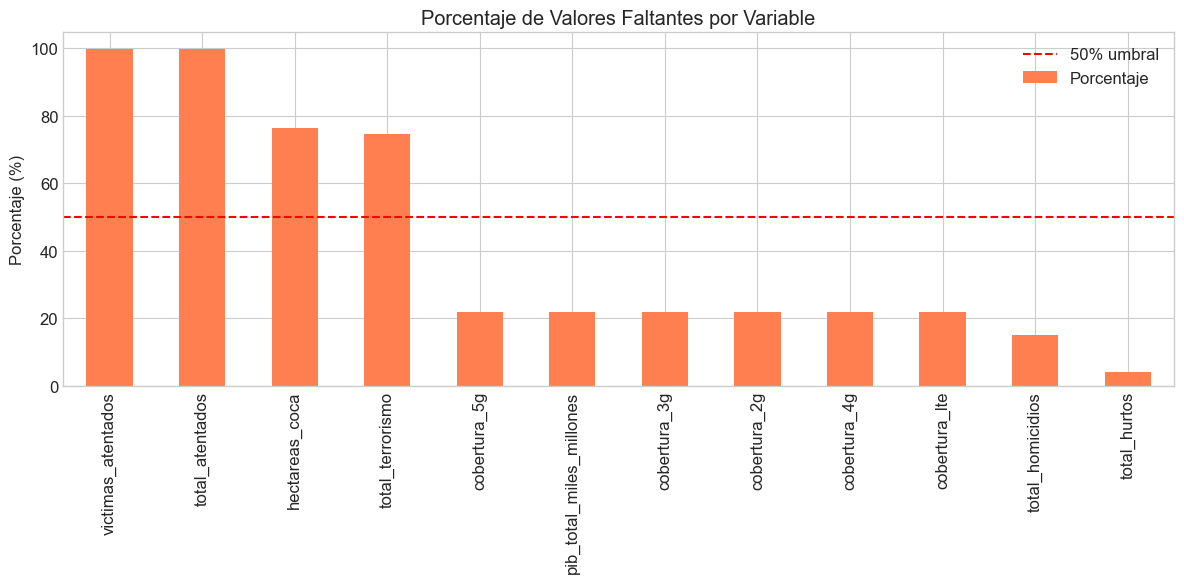

In [5]:
print("\nVALORES FALTANTES")
print("-"*50)

# Calcular valores faltantes
missing = datos.isnull().sum()
missing_pct = (missing / len(datos) * 100).round(2)
missing_df = pd.DataFrame({
    'Faltantes': missing,
    'Porcentaje': missing_pct
}).sort_values('Porcentaje', ascending=False)

display(missing_df[missing_df['Faltantes'] > 0])

# Visualizar valores faltantes
plt.figure(figsize=(12, 6))
missing_df[missing_df['Faltantes'] > 0]['Porcentaje'].plot(kind='bar', color='coral')
plt.title('Porcentaje de Valores Faltantes por Variable')
plt.ylabel('Porcentaje (%)')
plt.axhline(y=50, color='r', linestyle='--', label='50% umbral')
plt.legend()
plt.tight_layout()
save_figure('valores_faltantes')
plt.show()


RANGO DE ANOS
--------------------------------------------------
Anos disponibles: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Rango: 2016 - 2025

REGISTROS POR ANO
--------------------------------------------------
ano
2016    580
2017    624
2018    721
2019    758
2020    731
2021    729
2022    747
2023    761
2024    813
2025    771
dtype: int64
Grafico guardado: generated_data/model_outputs/02_registros_por_ano.png


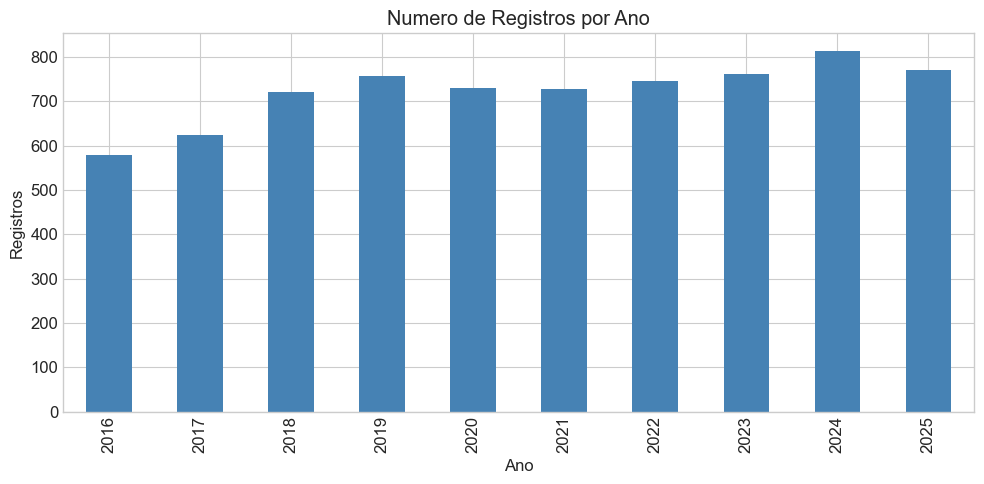

In [6]:
print("\nRANGO DE ANOS")
print("-"*50)
print(f"Anos disponibles: {sorted(datos['ano'].unique())}")
print(f"Rango: {datos['ano'].min()} - {datos['ano'].max()}")

print("\nREGISTROS POR ANO")
print("-"*50)
registros_ano = datos.groupby('ano').size()
print(registros_ano)

# Visualizar registros por ano
plt.figure(figsize=(10, 5))
registros_ano.plot(kind='bar', color='steelblue')
plt.title('Numero de Registros por Ano')
plt.xlabel('Ano')
plt.ylabel('Registros')
plt.tight_layout()
save_figure('registros_por_ano')
plt.show()

---
## 4. Analisis de Series de Tiempo

In [7]:
print("="*80)
print("ANALISIS DE SERIES DE TIEMPO".center(80))
print("="*80)

# Variables para analisis temporal
temporal_vars = [target] + [v for v in feature_vars if v in datos.columns]

# Agregar por ano
tendencias = datos.groupby('ano')[temporal_vars].agg(['sum', 'mean', 'count']).reset_index()

print("\nTendencia de la variable objetivo (total_extorsion):")
extorsion_anual = datos.groupby('ano')[target].agg(['sum', 'mean', 'count'])
extorsion_anual.columns = ['Total', 'Promedio', 'Municipios']
display(extorsion_anual)

                          ANALISIS DE SERIES DE TIEMPO                          

Tendencia de la variable objetivo (total_extorsion):


,Total,Promedio,Municipios
ano,,,
2016,4902,8.451724,580
2017,5532,8.865385,624
2018,7048,9.775312,721
2019,8362,11.031662,758
2020,8188,11.201094,731
2021,8342,11.443073,729
2022,9791,13.107095,747
2023,11078,14.557162,761
2024,13802,16.976630,813


Grafico guardado: generated_data/model_outputs/03_tendencia_extorsion.png


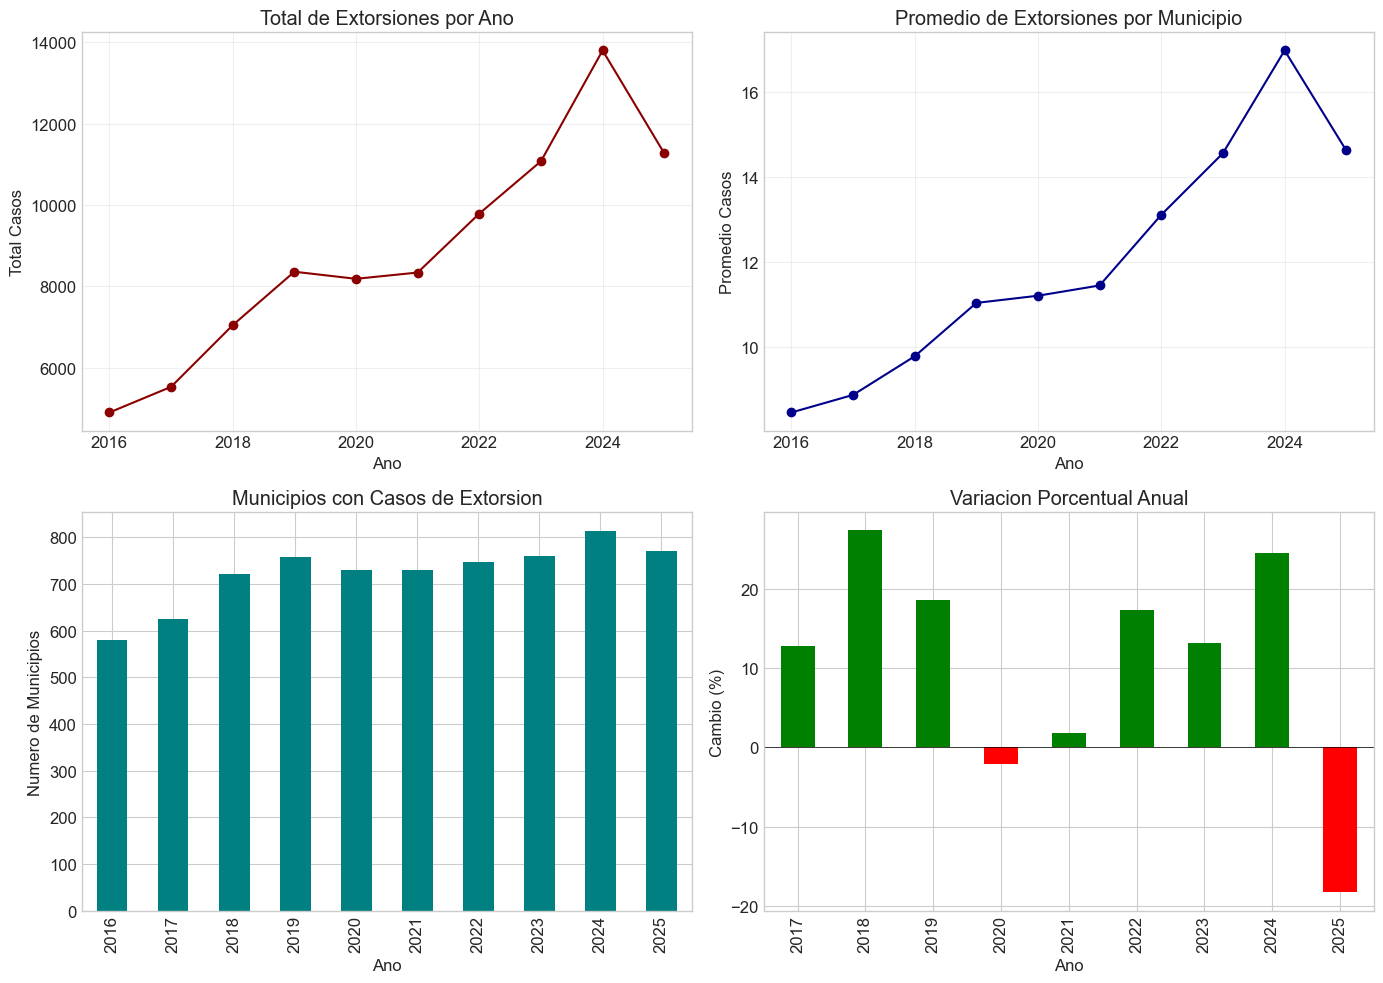

In [8]:
# Grafico de tendencia de extorsion
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Total de extorsiones por ano
ax1 = axes[0, 0]
extorsion_anual['Total'].plot(kind='line', marker='o', ax=ax1, color='darkred')
ax1.set_title('Total de Extorsiones por Ano')
ax1.set_xlabel('Ano')
ax1.set_ylabel('Total Casos')
ax1.grid(True, alpha=0.3)

# Promedio de extorsiones por municipio
ax2 = axes[0, 1]
extorsion_anual['Promedio'].plot(kind='line', marker='o', ax=ax2, color='darkblue')
ax2.set_title('Promedio de Extorsiones por Municipio')
ax2.set_xlabel('Ano')
ax2.set_ylabel('Promedio Casos')
ax2.grid(True, alpha=0.3)

# Numero de municipios con extorsiones
ax3 = axes[1, 0]
extorsion_anual['Municipios'].plot(kind='bar', ax=ax3, color='teal')
ax3.set_title('Municipios con Casos de Extorsion')
ax3.set_xlabel('Ano')
ax3.set_ylabel('Numero de Municipios')

# Tasa de cambio anual
ax4 = axes[1, 1]
cambio_pct = extorsion_anual['Total'].pct_change() * 100
colors = ['green' if x >= 0 else 'red' for x in cambio_pct.dropna()]
cambio_pct.dropna().plot(kind='bar', ax=ax4, color=colors)
ax4.set_title('Variacion Porcentual Anual')
ax4.set_xlabel('Ano')
ax4.set_ylabel('Cambio (%)')
ax4.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
save_figure('tendencia_extorsion')
plt.show()


TENDENCIAS TEMPORALES DE TODAS LAS VARIABLES
--------------------------------------------------
Grafico guardado: generated_data/model_outputs/04_series_tiempo_variables.png


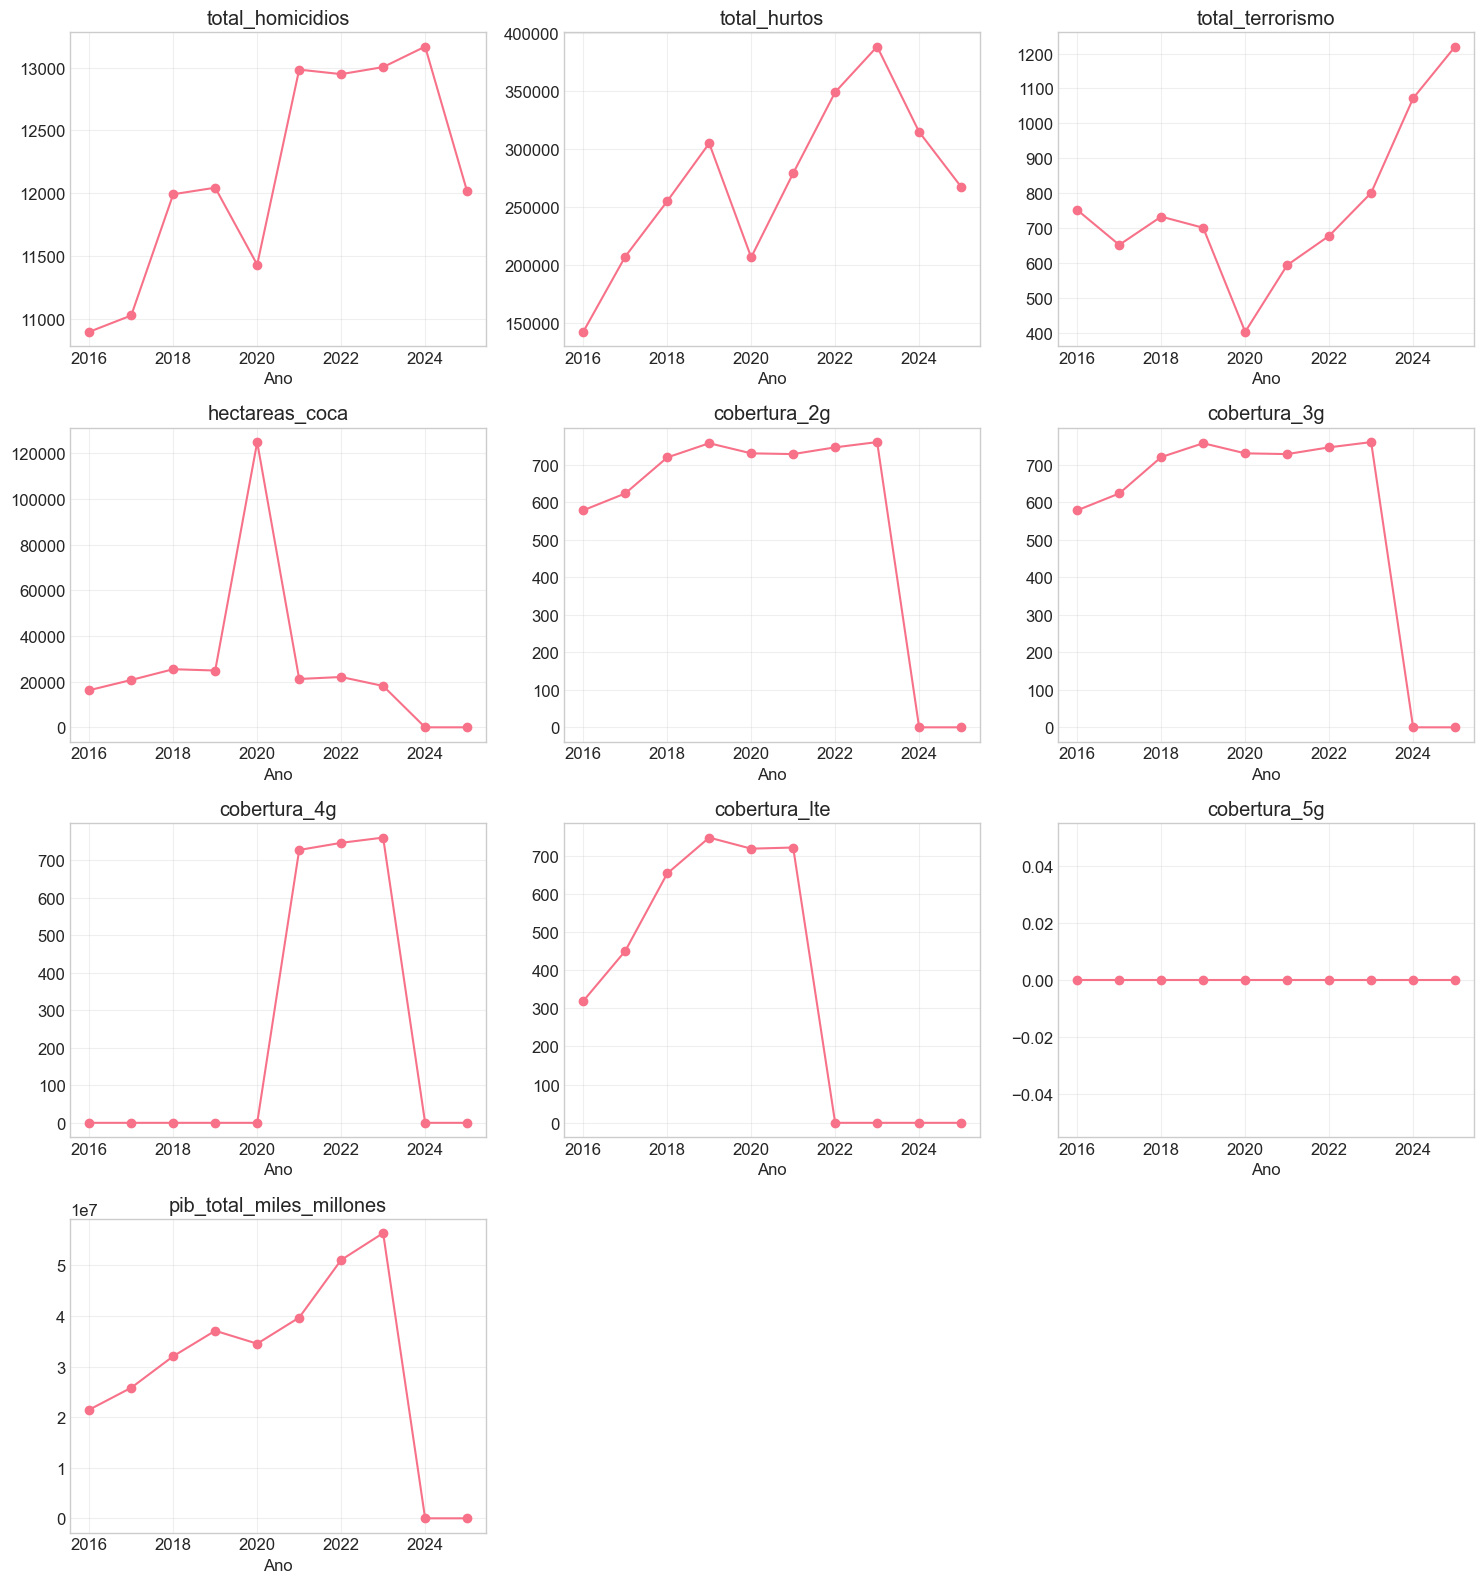

In [9]:
# Series de tiempo para todas las variables disponibles
print("\nTENDENCIAS TEMPORALES DE TODAS LAS VARIABLES")
print("-"*50)

# Variables con datos suficientes para series de tiempo
vars_temporales = [v for v in feature_vars if datos[v].notna().sum() > 100]

n_vars = len(vars_temporales)
n_cols = 3
n_rows = (n_vars + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes

for i, var in enumerate(vars_temporales):
    ax = axes[i]
    serie = datos.groupby('ano')[var].sum()
    serie.plot(kind='line', marker='o', ax=ax)
    ax.set_title(f'{var}')
    ax.set_xlabel('Ano')
    ax.grid(True, alpha=0.3)

# Ocultar ejes vacios
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
save_figure('series_tiempo_variables')
plt.show()

In [10]:
# Tabla resumen de tendencias
print("\nRESUMEN DE TENDENCIAS POR VARIABLE")
print("-"*50)

tendencias_resumen = []
for var in [target] + vars_temporales:
    serie = datos.groupby('ano')[var].sum()
    if len(serie) > 1:
        cambio_total = ((serie.iloc[-1] - serie.iloc[0]) / serie.iloc[0] * 100) if serie.iloc[0] != 0 else np.nan
        tendencias_resumen.append({
            'Variable': var,
            'Valor_Inicial': serie.iloc[0],
            'Valor_Final': serie.iloc[-1],
            'Cambio_%': round(cambio_total, 2),
            'Tendencia': 'Creciente' if cambio_total > 0 else 'Decreciente' if cambio_total < 0 else 'Estable'
        })

df_tendencias = pd.DataFrame(tendencias_resumen)
display(df_tendencias)


RESUMEN DE TENDENCIAS POR VARIABLE
--------------------------------------------------


,Variable,Valor_Inicial,Valor_Final,Cambio_%,Tendencia
0,total_extorsion,4902.00,11273.0,129.97,Creciente
1,total_homicidios,10899.00,12016.0,10.25,Creciente
2,total_hurtos,141981.00,267352.0,88.30,Creciente
3,total_terrorismo,752.00,1220.0,62.23,Creciente
4,hectareas_coca,16252.90,0.0,-100.00,Decreciente
5,cobertura_2g,579.00,0.0,-100.00,Decreciente
6,cobertura_3g,579.00,0.0,-100.00,Decreciente
7,cobertura_4g,0.00,0.0,NaN,Estable
8,cobertura_lte,319.00,0.0,-100.00,Decreciente
9,cobertura_5g,0.00,0.0,NaN,Estable


---
## 5. Analisis de Distribucion de Variables

In [11]:
print("="*80)
print("ANALISIS DE DISTRIBUCION DE VARIABLES".center(80))
print("="*80)

# Estadisticas de la variable objetivo
print(f"\nEstadisticas de {target}:")
print(datos[target].describe())

# Deteccion de outliers
Q1 = datos[target].quantile(0.25)
Q3 = datos[target].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = datos[(datos[target] < lower_bound) | (datos[target] > upper_bound)]

print(f"\nDeteccion de valores atipicos:")
print(f"   - Rango intercuartil (IQR): {IQR:.2f}")
print(f"   - Limite inferior: {lower_bound:.2f}")
print(f"   - Limite superior: {upper_bound:.2f}")
print(f"   - Valores atipicos: {len(outliers)} ({len(outliers)/len(datos)*100:.2f}% del total)")

                     ANALISIS DE DISTRIBUCION DE VARIABLES                      

Estadisticas de total_extorsion:
count    7235.000000
mean       12.207049
std        68.307735
min         1.000000
25%         1.000000
50%         3.000000
75%         6.000000
max      2641.000000
Name: total_extorsion, dtype: float64

Deteccion de valores atipicos:
   - Rango intercuartil (IQR): 5.00
   - Limite inferior: -6.50
   - Limite superior: 13.50
   - Valores atipicos: 874 (12.08% del total)


Grafico guardado: generated_data/model_outputs/05_distribucion_variable_objetivo.png


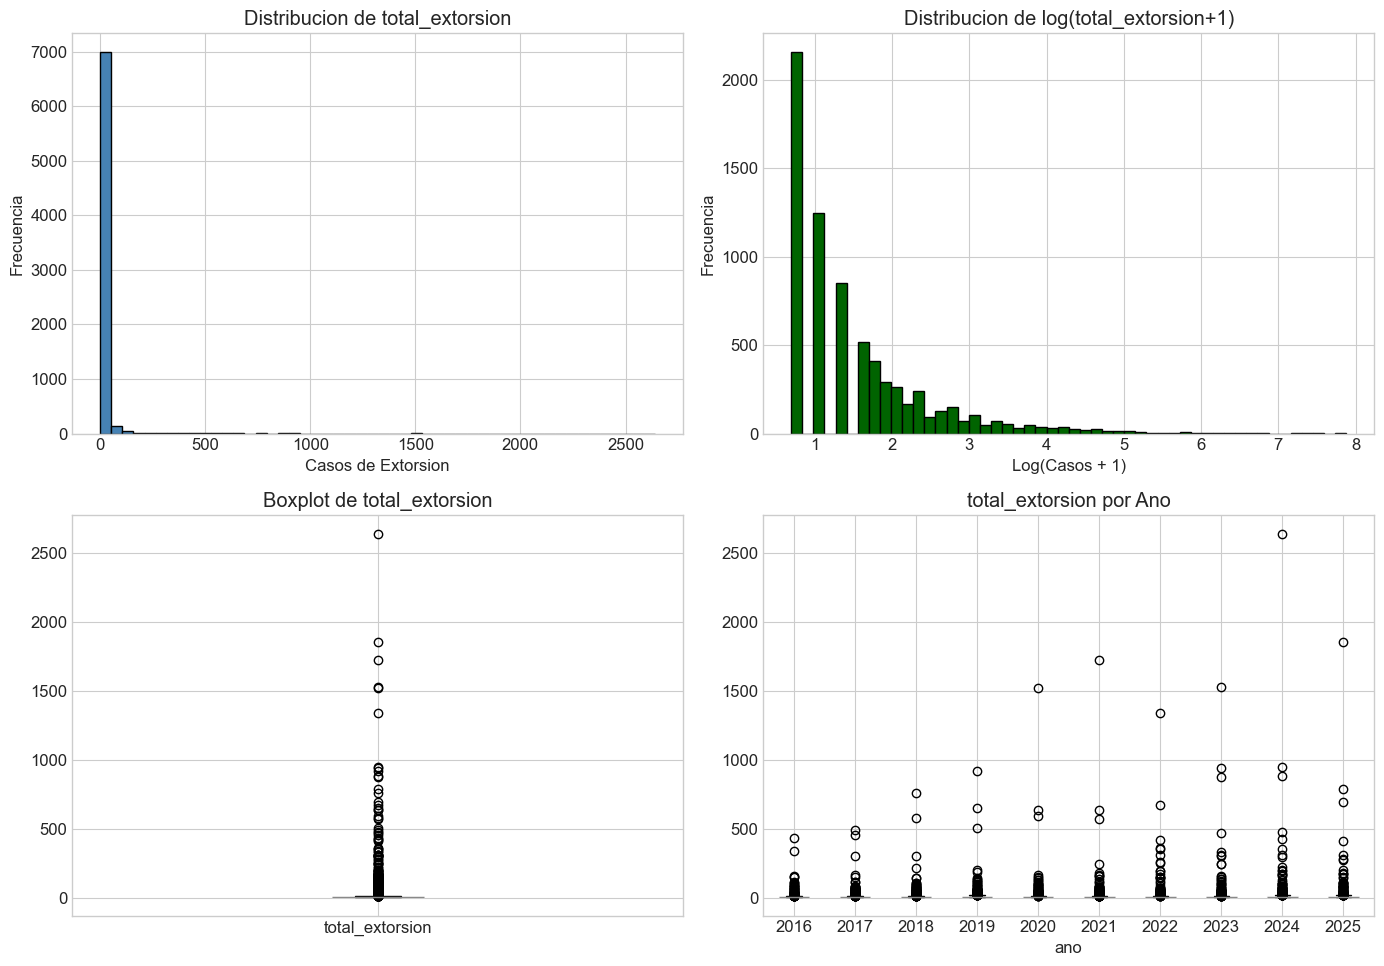

In [12]:
# Distribucion de la variable objetivo
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histograma
ax1 = axes[0, 0]
datos[target].hist(bins=50, ax=ax1, color='steelblue', edgecolor='black')
ax1.set_title(f'Distribucion de {target}')
ax1.set_xlabel('Casos de Extorsion')
ax1.set_ylabel('Frecuencia')

# Histograma con transformacion log
ax2 = axes[0, 1]
np.log1p(datos[target]).hist(bins=50, ax=ax2, color='darkgreen', edgecolor='black')
ax2.set_title(f'Distribucion de log({target}+1)')
ax2.set_xlabel('Log(Casos + 1)')
ax2.set_ylabel('Frecuencia')

# Boxplot
ax3 = axes[1, 0]
datos.boxplot(column=target, ax=ax3)
ax3.set_title(f'Boxplot de {target}')

# Boxplot por ano
ax4 = axes[1, 1]
datos.boxplot(column=target, by='ano', ax=ax4)
ax4.set_title(f'{target} por Ano')
plt.suptitle('')

plt.tight_layout()
save_figure('distribucion_variable_objetivo')
plt.show()

Grafico guardado: generated_data/model_outputs/06_distribucion_variables.png


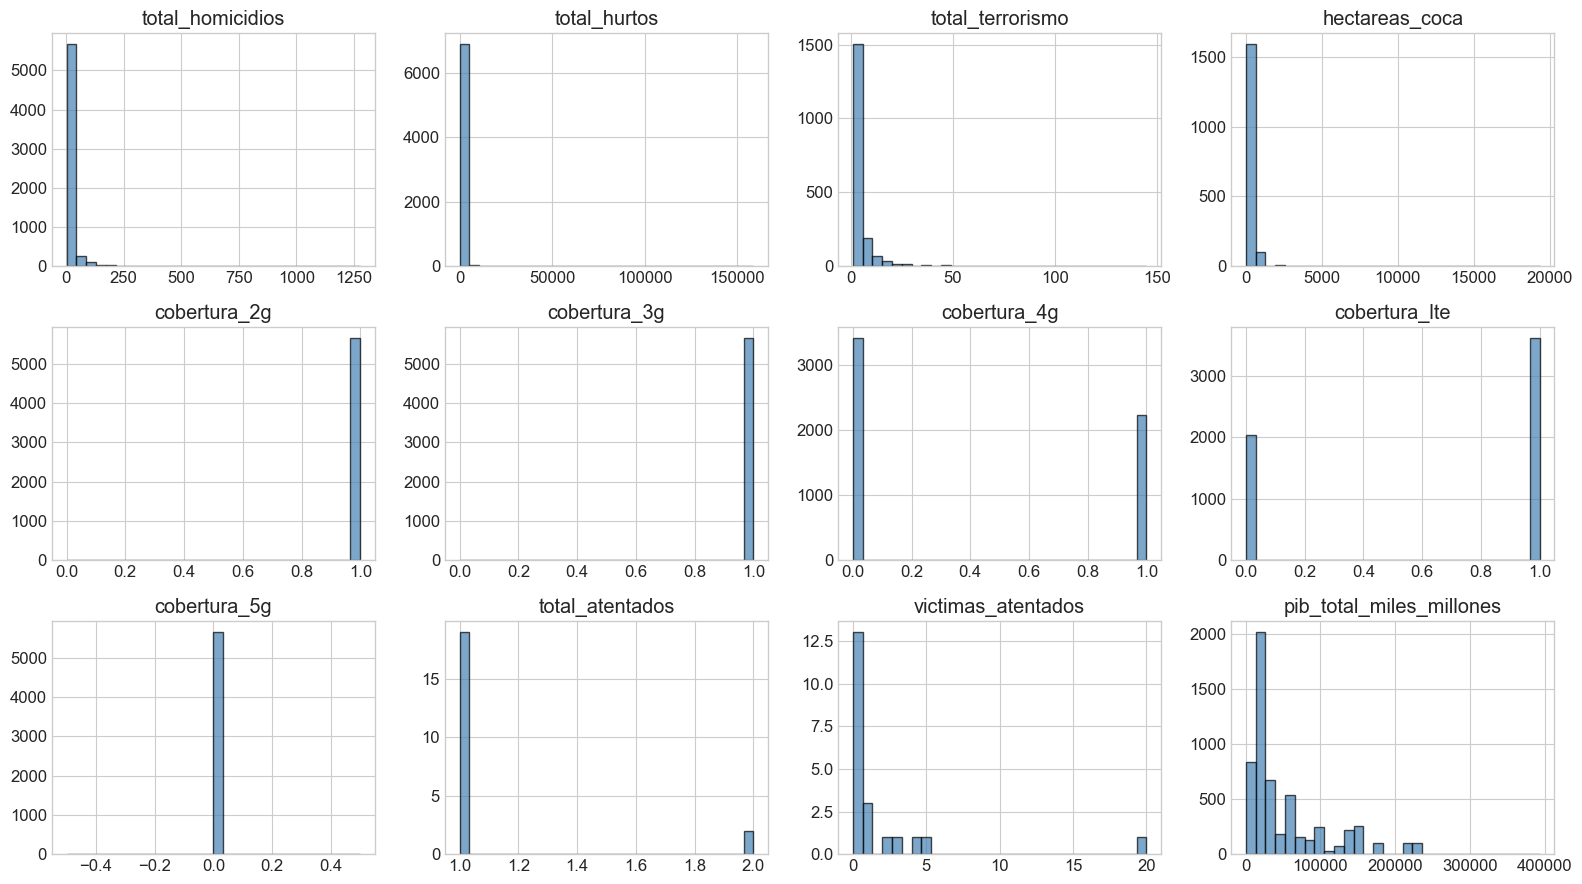

In [13]:
# Distribucion de todas las variables numericas
numeric_vars = datos[feature_vars].select_dtypes(include=[np.number]).columns.tolist()

n_vars = len(numeric_vars)
n_cols = 4
n_rows = (n_vars + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3*n_rows))
axes = axes.flatten()

for i, var in enumerate(numeric_vars):
    ax = axes[i]
    datos[var].dropna().hist(bins=30, ax=ax, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_title(f'{var}')
    ax.set_xlabel('')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
save_figure('distribucion_variables')
plt.show()

---
## 6. Analisis de Correlaciones

In [14]:
print("="*80)
print("ANALISIS DE CORRELACIONES".center(80))
print("="*80)

# Seleccionar variables numericas para correlacion
corr_vars = [target] + [v for v in feature_vars if v in datos.columns]
df_corr = datos[corr_vars].dropna()

print(f"\nVariables incluidas en correlacion: {len(corr_vars)}")
print(f"Registros con datos completos: {len(df_corr):,}")

                           ANALISIS DE CORRELACIONES                            

Variables incluidas en correlacion: 13
Registros con datos completos: 12



MATRIZ DE CORRELACION (todos los datos disponibles)
--------------------------------------------------
Grafico guardado: generated_data/model_outputs/07_matriz_correlacion_completa.png


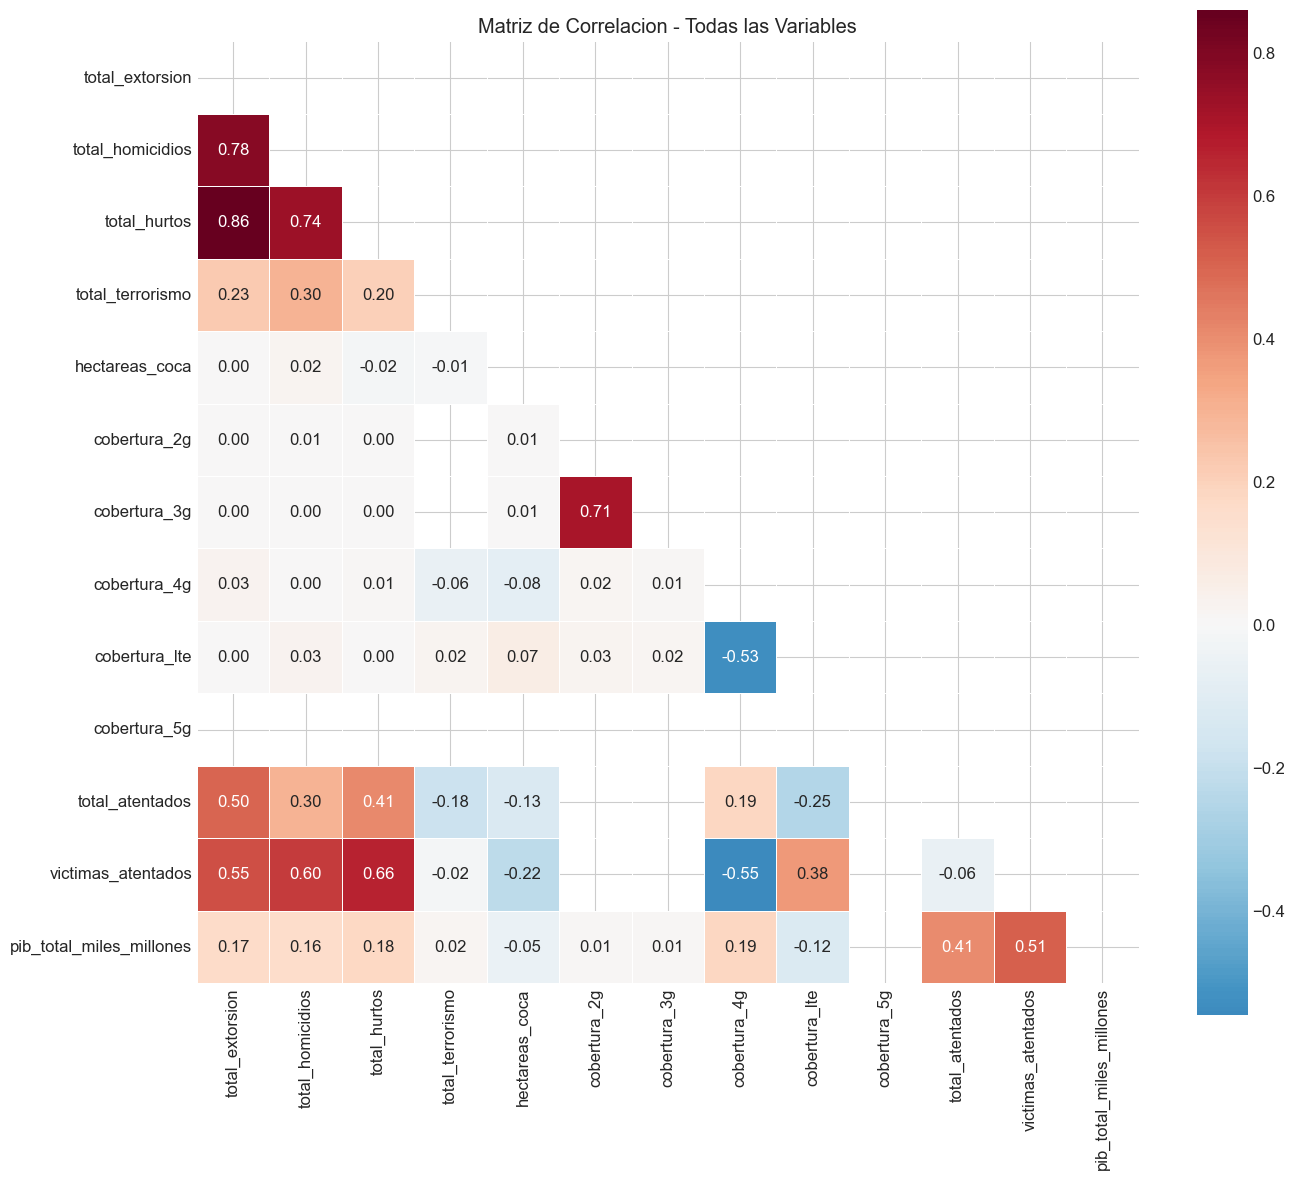

In [15]:
# Matriz de correlacion completa
print("\nMATRIZ DE CORRELACION (todos los datos disponibles)")
print("-"*50)

# Usar correlacion por pares (ignora NaN)
corr_matrix = datos[corr_vars].corr()

plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, square=True, linewidths=0.5)
plt.title('Matriz de Correlacion - Todas las Variables')
plt.tight_layout()
save_figure('matriz_correlacion_completa')
plt.show()


CORRELACION CON VARIABLE OBJETIVO
--------------------------------------------------
total_hurtos                0.859893
total_homicidios            0.780390
victimas_atentados          0.554896
total_atentados             0.500976
total_terrorismo            0.227735
pib_total_miles_millones    0.167447
cobertura_4g                0.026124
cobertura_lte               0.003412
hectareas_coca              0.003069
cobertura_3g                0.002338
cobertura_2g                0.002334
cobertura_5g                     NaN
Name: total_extorsion, dtype: float64
Grafico guardado: generated_data/model_outputs/08_correlacion_con_objetivo.png


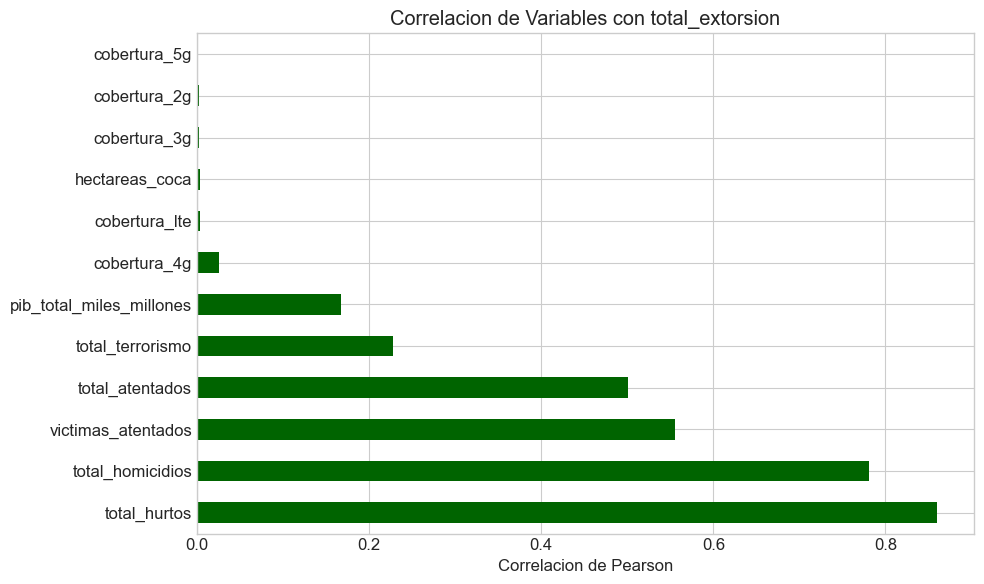

In [16]:
# Correlacion con la variable objetivo
print("\nCORRELACION CON VARIABLE OBJETIVO")
print("-"*50)

corr_with_target = corr_matrix[target].drop(target).sort_values(ascending=False)
print(corr_with_target)

# Visualizar
plt.figure(figsize=(10, 6))
colors = ['darkgreen' if x > 0 else 'darkred' for x in corr_with_target.values]
corr_with_target.plot(kind='barh', color=colors)
plt.title(f'Correlacion de Variables con {target}')
plt.xlabel('Correlacion de Pearson')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
save_figure('correlacion_con_objetivo')
plt.show()


MATRICES DE CORRELACION POR PERIODO
--------------------------------------------------
Grafico guardado: generated_data/model_outputs/09_correlacion_por_periodo.png


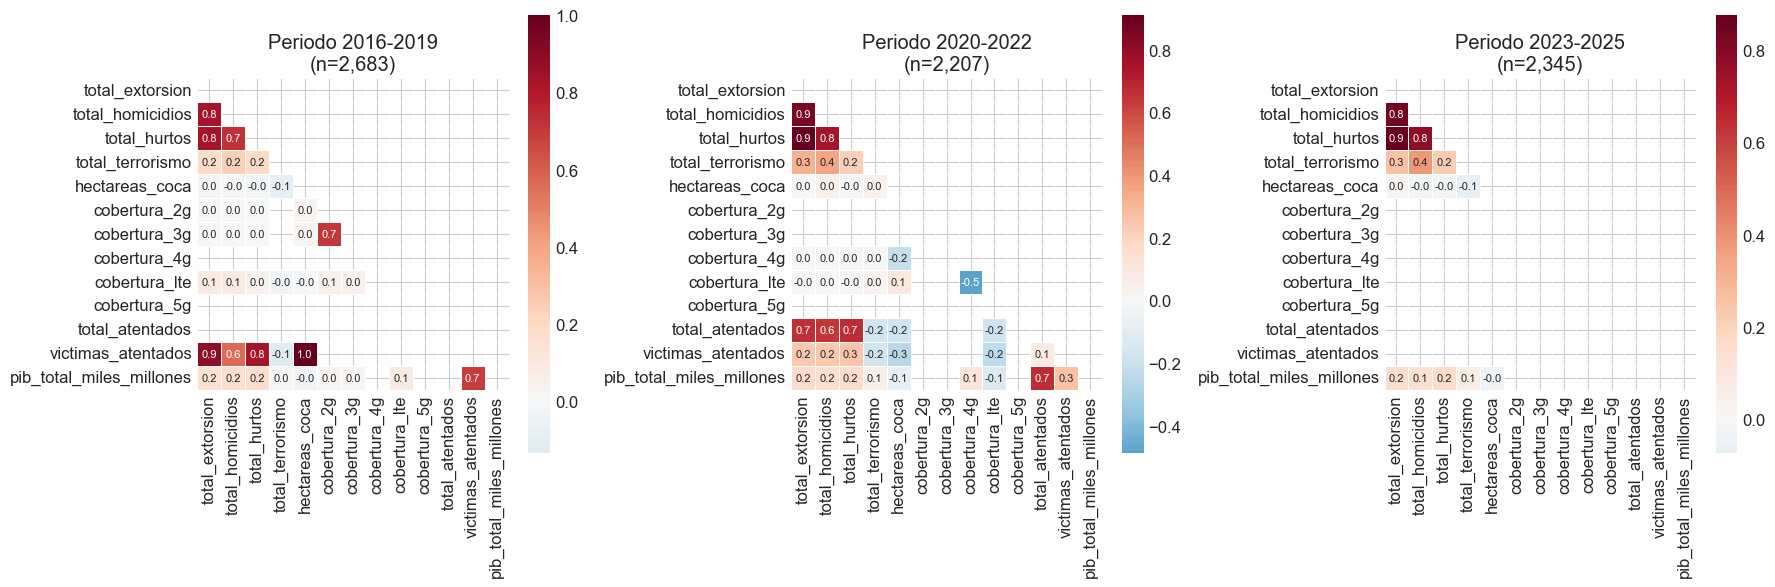

In [17]:
# Matrices de correlacion por periodos (anos comunes)
print("\nMATRICES DE CORRELACION POR PERIODO")
print("-"*50)

# Definir periodos
periodos = {
    '2016-2019': (2016, 2019),
    '2020-2022': (2020, 2022),
    '2023-2025': (2023, 2025)
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, (periodo, (ano_ini, ano_fin)) in enumerate(periodos.items()):
    df_periodo = datos[(datos['ano'] >= ano_ini) & (datos['ano'] <= ano_fin)]
    
    if len(df_periodo) > 10:
        corr_periodo = df_periodo[corr_vars].corr()
        
        ax = axes[idx]
        mask = np.triu(np.ones_like(corr_periodo, dtype=bool))
        sns.heatmap(corr_periodo, mask=mask, annot=True, fmt='.1f', cmap='RdBu_r',
                    center=0, square=True, linewidths=0.5, ax=ax, annot_kws={'size': 8})
        ax.set_title(f'Periodo {periodo}\n(n={len(df_periodo):,})')

plt.tight_layout()
save_figure('correlacion_por_periodo')
plt.show()

In [18]:
# Analisis de multicolinealidad
print("\nANALISIS DE MULTICOLINEALIDAD")
print("-"*50)

threshold_multi = 0.8
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > threshold_multi:
            high_corr_pairs.append({
                'Variable_1': corr_matrix.columns[i],
                'Variable_2': corr_matrix.columns[j],
                'Correlacion': corr_matrix.iloc[i, j]
            })

if high_corr_pairs:
    df_multi = pd.DataFrame(high_corr_pairs)
    print(f"Pares de variables con alta multicolinealidad (|r| > {threshold_multi}):")
    display(df_multi)
else:
    print(f"No se encontraron pares con correlacion > {threshold_multi}")


ANALISIS DE MULTICOLINEALIDAD
--------------------------------------------------
Pares de variables con alta multicolinealidad (|r| > 0.8):


,Variable_1,Variable_2,Correlacion
0,total_extorsion,total_hurtos,0.859893


---
## 7. Seleccion de Variables y Limpieza Final

In [19]:
print("="*80)
print("SELECCION DE VARIABLES PARA MODELADO".center(80))
print("="*80)

# Criterios de seleccion:
# 1. Variables con menos de 50% de valores faltantes
# 2. Variables con correlacion significativa con el objetivo
# 3. Evitar multicolinealidad alta

# Filtrar por valores faltantes
threshold_missing = 50
vars_con_datos = [v for v in feature_vars if missing_pct.get(v, 0) < threshold_missing]
print(f"\nVariables con < {threshold_missing}% faltantes: {vars_con_datos}")

# Seleccion final de features
# Priorizar variables con datos hasta 2025
features_modelo = []
for var in vars_con_datos:
    # Verificar que tiene datos en anos recientes
    datos_recientes = datos[datos['ano'] >= 2023][var].notna().sum()
    if datos_recientes > 100:  # Al menos 100 registros en anos recientes
        features_modelo.append(var)

# Agregar ano como feature
features_modelo = ['ano', 'cod_dpto', 'cod_mun'] + features_modelo

print(f"\nFeatures seleccionadas para modelado ({len(features_modelo)}):")
for f in features_modelo:
    print(f"   - {f}")

                      SELECCION DE VARIABLES PARA MODELADO                      

Variables con < 50% faltantes: ['total_homicidios', 'total_hurtos', 'cobertura_2g', 'cobertura_3g', 'cobertura_4g', 'cobertura_lte', 'cobertura_5g', 'pib_total_miles_millones']

Features seleccionadas para modelado (11):
   - ano
   - cod_dpto
   - cod_mun
   - total_homicidios
   - total_hurtos
   - cobertura_2g
   - cobertura_3g
   - cobertura_4g
   - cobertura_lte
   - cobertura_5g
   - pib_total_miles_millones


In [20]:
# Crear dataset limpio para modelado
print("\nPREPARACION DEL DATASET PARA MODELADO")
print("-"*50)

# Filtrar registros con variable objetivo valida
df = datos[datos[target].notna()].copy()
print(f"Registros con {target} valido: {len(df):,}")

# Convertir codigos a string para tratarlos como categoricos
df['cod_dpto'] = df['cod_dpto'].astype(str)
df['cod_mun'] = df['cod_mun'].astype(str)

# Imputar valores faltantes en features numericas
numeric_features = [f for f in features_modelo if f not in ['cod_dpto', 'cod_mun', 'ano']]
for col in numeric_features:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

print(f"\nDataset final: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"Anos incluidos: {sorted(df['ano'].unique())}")


PREPARACION DEL DATASET PARA MODELADO
--------------------------------------------------
Registros con total_extorsion valido: 7,235

Dataset final: 7,235 filas x 18 columnas
Anos incluidos: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


---
## 8. Division Temporal de Datos

In [21]:
print("="*80)
print("DIVISION TEMPORAL DE DATOS".center(80))
print("="*80)

# Anos disponibles
anos_disponibles = sorted(df['ano'].unique())
print(f"\nAnos disponibles: {anos_disponibles}")

# Division temporal: entrenar con datos historicos, probar con recientes
# Usar 2024-2025 como test (datos mas recientes)
train_years = [a for a in anos_disponibles if a <= 2023]
test_years = [a for a in anos_disponibles if a >= 2024]

print(f"\nEstrategia de division temporal:")
print(f"   - Anos para entrenamiento: {train_years}")
print(f"   - Anos para prueba: {test_years}")

# Crear conjuntos
df_train = df[df['ano'].isin(train_years)].copy()
df_test = df[df['ano'].isin(test_years)].copy()

# Features disponibles en el dataset
features = [f for f in features_modelo if f in df.columns]

print(f"\nVariables predictoras: {features}")
print(f"Variable objetivo: {target}")

# Separar X e y
X_train = df_train[features]
y_train = df_train[target]
X_test = df_test[features]
y_test = df_test[target]

print(f"\nTamano de conjuntos:")
print(f"   - Entrenamiento: {len(X_train):,} registros ({len(X_train)/len(df)*100:.1f}%)")
print(f"   - Prueba: {len(X_test):,} registros ({len(X_test)/len(df)*100:.1f}%)")

                           DIVISION TEMPORAL DE DATOS                           

Anos disponibles: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

Estrategia de division temporal:
   - Anos para entrenamiento: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
   - Anos para prueba: [np.int64(2024), np.int64(2025)]

Variables predictoras: ['ano', 'cod_dpto', 'cod_mun', 'total_homicidios', 'total_hurtos', 'cobertura_2g', 'cobertura_3g', 'cobertura_4g', 'cobertura_lte', 'cobertura_5g', 'pib_total_miles_millones']
Variable objetivo: total_extorsion

Tamano de conjuntos:
   - Entrenamiento: 5,651 registros (78.1%)
   - Prueba: 1,584 registros (21.9%)



Comparacion estadistica de la variable objetivo:


,Entrenamiento,Prueba
count,5651.000000,1584.000000
mean,11.191471,15.830177
std,57.989356,96.453902
min,1.000000,1.000000
25%,1.000000,1.000000
50%,3.000000,3.000000
75%,6.000000,7.000000
max,1721.000000,2641.000000


Grafico guardado: generated_data/model_outputs/10_distribucion_train_test.png


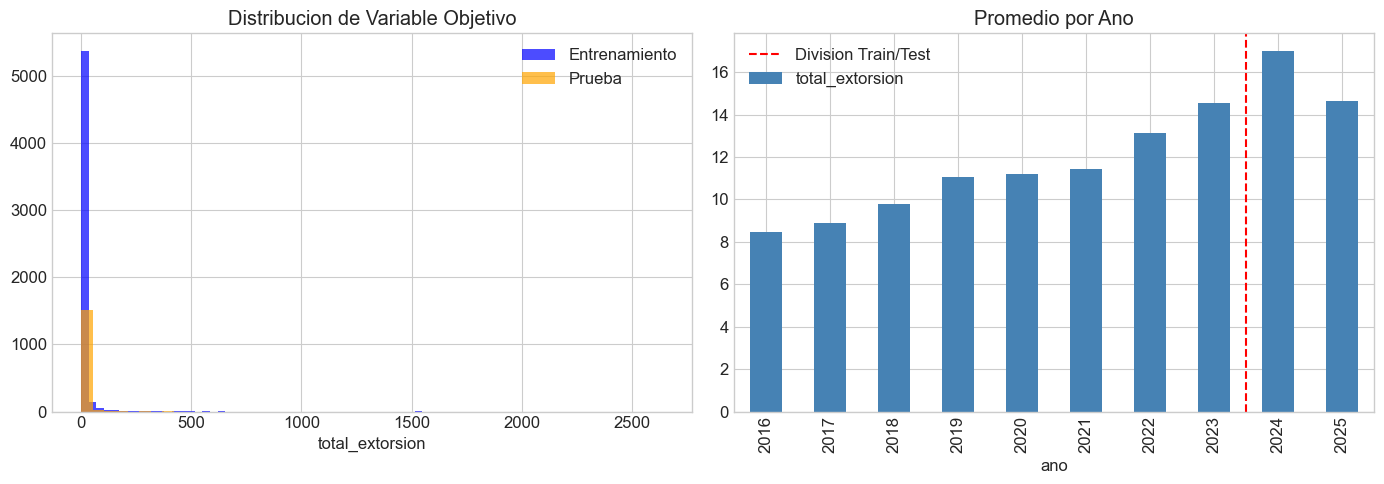

In [22]:
# Comparacion estadistica
print("\nComparacion estadistica de la variable objetivo:")
stats_comparison = pd.DataFrame({
    'Entrenamiento': y_train.describe(),
    'Prueba': y_test.describe()
})
display(stats_comparison)

# Visualizar distribucion
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
y_train.hist(bins=50, ax=ax1, alpha=0.7, label='Entrenamiento', color='blue')
y_test.hist(bins=50, ax=ax1, alpha=0.7, label='Prueba', color='orange')
ax1.set_title('Distribucion de Variable Objetivo')
ax1.set_xlabel(target)
ax1.legend()

ax2 = axes[1]
df.groupby('ano')[target].mean().plot(kind='bar', ax=ax2, color='steelblue')
ax2.axvline(x=len(train_years)-0.5, color='red', linestyle='--', label='Division Train/Test')
ax2.set_title('Promedio por Ano')
ax2.legend()

plt.tight_layout()
save_figure('distribucion_train_test')
plt.show()

---
## 9. Configuracion del Pipeline

In [23]:
print("="*80)
print("CONFIGURACION DEL PIPELINE".center(80))
print("="*80)

# Identificar tipos de variables
categorical_features = ['cod_dpto', 'cod_mun']
categorical_features = [f for f in categorical_features if f in features]

numeric_features = [f for f in features if f not in categorical_features]

print(f"\nVariables categoricas: {categorical_features}")
print(f"Variables numericas: {numeric_features}")

# Preprocesadores
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combinar preprocesadores
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

print("\nPipeline de preprocesamiento configurado")

                           CONFIGURACION DEL PIPELINE                           

Variables categoricas: ['cod_dpto', 'cod_mun']
Variables numericas: ['ano', 'total_homicidios', 'total_hurtos', 'cobertura_2g', 'cobertura_3g', 'cobertura_4g', 'cobertura_lte', 'cobertura_5g', 'pib_total_miles_millones']

Pipeline de preprocesamiento configurado


---
## 10. Entrenamiento de Modelos

In [24]:
print("="*80)
print("ENTRENAMIENTO DE MODELOS".center(80))
print("="*80)

# Definir modelos
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

# Almacenar resultados
results = {}
trained_models = {}

for name, model in models.items():
    print(f"\nEntrenando {name}...")
    start_time = time.time()
    
    # Crear pipeline
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    
    # Entrenar
    pipeline.fit(X_train, y_train)
    
    # Predicciones
    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)
    
    # Metricas
    results[name] = {
        'MAE (Train)': mean_absolute_error(y_train, y_train_pred),
        'MAE (Test)': mean_absolute_error(y_test, y_test_pred),
        'RMSE (Train)': np.sqrt(mean_squared_error(y_train, y_train_pred)),
        'RMSE (Test)': np.sqrt(mean_squared_error(y_test, y_test_pred)),
        'R2 (Train)': r2_score(y_train, y_train_pred),
        'R2 (Test)': r2_score(y_test, y_test_pred),
        'Tiempo (s)': time.time() - start_time
    }
    
    trained_models[name] = pipeline
    
    print(f"   MAE (Test): {results[name]['MAE (Test)']:.2f}")
    print(f"   R2 (Test): {results[name]['R2 (Test)']:.4f}")
    print(f"   Tiempo: {results[name]['Tiempo (s)']:.2f}s")

                            ENTRENAMIENTO DE MODELOS                            

Entrenando Linear Regression...
   MAE (Test): 9.63
   R2 (Test): 0.7685
   Tiempo: 1.36s

Entrenando Random Forest...
   MAE (Test): 7.56
   R2 (Test): 0.6085
   Tiempo: 26.08s

Entrenando Gradient Boosting...
   MAE (Test): 7.70
   R2 (Test): 0.6222
   Tiempo: 42.24s

Entrenando XGBoost...
   MAE (Test): 8.43
   R2 (Test): 0.3208
   Tiempo: 1.02s


---
## 11. Comparacion de Modelos

In [25]:
print("="*80)
print("COMPARACION DE MODELOS".center(80))
print("="*80)

# Tabla comparativa
results_df = pd.DataFrame(results).T
print("\nResultados de todos los modelos:")
display(results_df.round(4))

# Guardar resultados
results_df.to_csv(f'{output_dir}/comparacion_modelos.csv')
print(f"\nResultados guardados: {output_dir}/comparacion_modelos.csv")

                             COMPARACION DE MODELOS                             

Resultados de todos los modelos:


,MAE (Train),MAE (Test),RMSE (Train),RMSE (Test),R2 (Train),R2 (Test),Tiempo (s)
Linear Regression,4.0569,9.6333,19.8891,46.3958,0.8823,0.7685,1.3607
Random Forest,1.3850,7.5585,7.4317,60.3303,0.9836,0.6085,26.0784
Gradient Boosting,3.2801,7.7003,6.9916,59.2648,0.9855,0.6222,42.2446
XGBoost,1.7479,8.4327,2.7011,79.4653,0.9978,0.3208,1.0206



Resultados guardados: generated_data/model_outputs/comparacion_modelos.csv


Grafico guardado: generated_data/model_outputs/11_comparacion_modelos.png


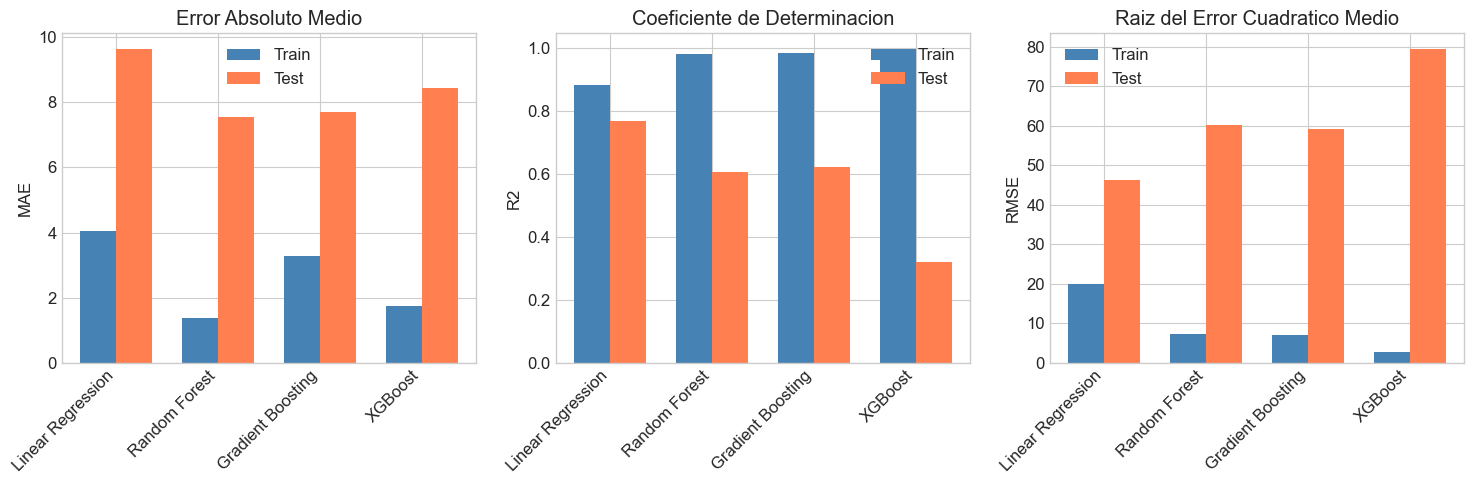

In [26]:
# Visualizacion comparativa
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# MAE
ax1 = axes[0]
x = np.arange(len(results))
width = 0.35
ax1.bar(x - width/2, results_df['MAE (Train)'], width, label='Train', color='steelblue')
ax1.bar(x + width/2, results_df['MAE (Test)'], width, label='Test', color='coral')
ax1.set_ylabel('MAE')
ax1.set_title('Error Absoluto Medio')
ax1.set_xticks(x)
ax1.set_xticklabels(results_df.index, rotation=45, ha='right')
ax1.legend()

# R2
ax2 = axes[1]
ax2.bar(x - width/2, results_df['R2 (Train)'], width, label='Train', color='steelblue')
ax2.bar(x + width/2, results_df['R2 (Test)'], width, label='Test', color='coral')
ax2.set_ylabel('R2')
ax2.set_title('Coeficiente de Determinacion')
ax2.set_xticks(x)
ax2.set_xticklabels(results_df.index, rotation=45, ha='right')
ax2.legend()

# RMSE
ax3 = axes[2]
ax3.bar(x - width/2, results_df['RMSE (Train)'], width, label='Train', color='steelblue')
ax3.bar(x + width/2, results_df['RMSE (Test)'], width, label='Test', color='coral')
ax3.set_ylabel('RMSE')
ax3.set_title('Raiz del Error Cuadratico Medio')
ax3.set_xticks(x)
ax3.set_xticklabels(results_df.index, rotation=45, ha='right')
ax3.legend()

plt.tight_layout()
save_figure('comparacion_modelos')
plt.show()

In [27]:
# Identificar mejores modelos
best_mae_model = results_df['MAE (Test)'].idxmin()
best_r2_model = results_df['R2 (Test)'].idxmax()

print(f"\nMejor modelo por MAE: {best_mae_model}")
print(f"   MAE (Test): {results_df.loc[best_mae_model, 'MAE (Test)']:.2f}")

print(f"\nMejor modelo por R2: {best_r2_model}")
print(f"   R2 (Test): {results_df.loc[best_r2_model, 'R2 (Test)']:.4f}")


Mejor modelo por MAE: Random Forest
   MAE (Test): 7.56

Mejor modelo por R2: Linear Regression
   R2 (Test): 0.7685


---
## 12. Analisis del Mejor Modelo

In [28]:
print("="*80)
print("ANALISIS DEL MEJOR MODELO".center(80))
print("="*80)

# Seleccionar mejor modelo (por R2)
best_model_name = best_r2_model
best_pipeline = trained_models[best_model_name]

print(f"\nModelo seleccionado: {best_model_name}")

# Predicciones del mejor modelo
y_pred = best_pipeline.predict(X_test)

# Analisis de residuos
residuos = y_test - y_pred

print(f"\nEstadisticas de residuos:")
print(f"   Media: {residuos.mean():.2f}")
print(f"   Desviacion estandar: {residuos.std():.2f}")
print(f"   Minimo: {residuos.min():.2f}")
print(f"   Maximo: {residuos.max():.2f}")

                           ANALISIS DEL MEJOR MODELO                            

Modelo seleccionado: Linear Regression

Estadisticas de residuos:
   Media: 2.54
   Desviacion estandar: 46.34
   Minimo: -49.35
   Maximo: 1346.35


Grafico guardado: generated_data/model_outputs/12_analisis_residuos_Linear_Regression.png


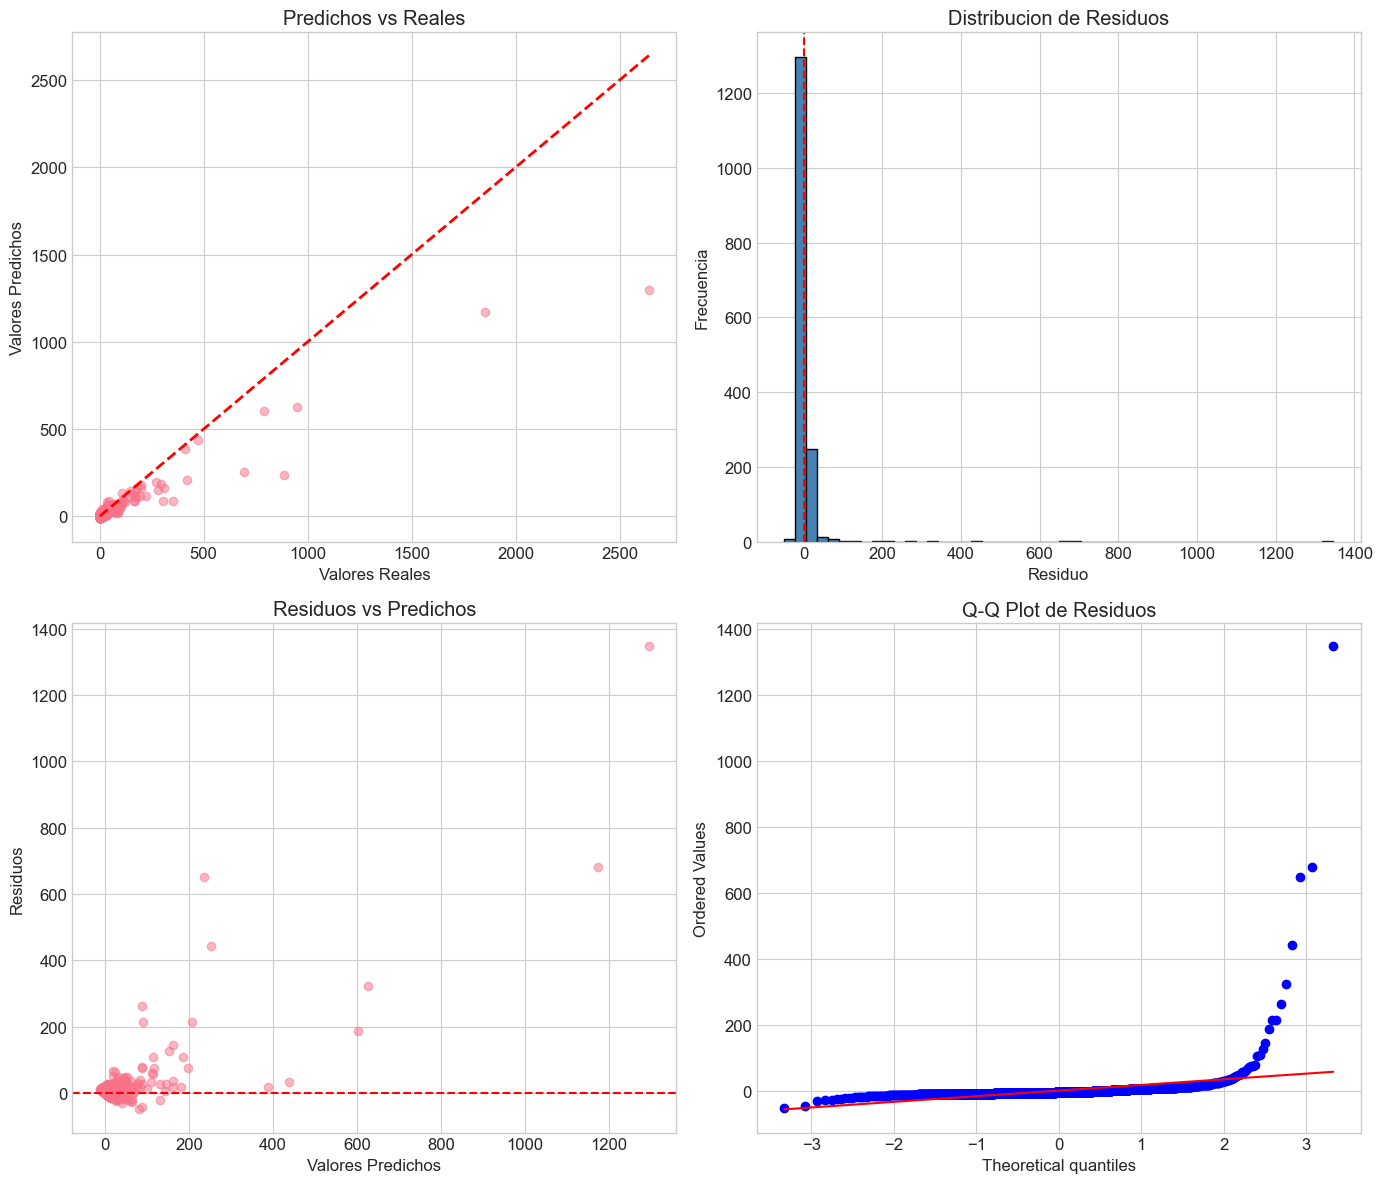

In [29]:
# Visualizacion de predicciones vs reales
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Predichos vs Reales
ax1 = axes[0, 0]
ax1.scatter(y_test, y_pred, alpha=0.5)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax1.set_xlabel('Valores Reales')
ax1.set_ylabel('Valores Predichos')
ax1.set_title('Predichos vs Reales')

# Distribucion de residuos
ax2 = axes[0, 1]
residuos.hist(bins=50, ax=ax2, color='steelblue', edgecolor='black')
ax2.axvline(x=0, color='red', linestyle='--')
ax2.set_xlabel('Residuo')
ax2.set_ylabel('Frecuencia')
ax2.set_title('Distribucion de Residuos')

# Residuos vs Predichos
ax3 = axes[1, 0]
ax3.scatter(y_pred, residuos, alpha=0.5)
ax3.axhline(y=0, color='red', linestyle='--')
ax3.set_xlabel('Valores Predichos')
ax3.set_ylabel('Residuos')
ax3.set_title('Residuos vs Predichos')

# QQ Plot
ax4 = axes[1, 1]
from scipy import stats
stats.probplot(residuos, dist="norm", plot=ax4)
ax4.set_title('Q-Q Plot de Residuos')

plt.tight_layout()
save_figure(f'analisis_residuos_{best_model_name.replace(" ", "_")}')
plt.show()

In [30]:
# Importancia de variables (si el modelo lo soporta)
print("\nIMPORTANCIA DE VARIABLES")
print("-"*50)

try:
    # Obtener el modelo del pipeline
    model = best_pipeline.named_steps['regressor']
    
    if hasattr(model, 'feature_importances_'):
        # Obtener nombres de features despues del preprocesamiento
        feature_names = numeric_features.copy()
        
        # Agregar nombres de features categoricas (one-hot encoded)
        if categorical_features:
            ohe = best_pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
            cat_feature_names = ohe.get_feature_names_out(categorical_features)
            feature_names.extend(cat_feature_names)
        
        # Crear DataFrame de importancia
        importance_df = pd.DataFrame({
            'Feature': feature_names,
            'Importance': model.feature_importances_
        }).sort_values('Importance', ascending=False)
        
        print("\nTop 15 variables mas importantes:")
        display(importance_df.head(15))
        
        # Visualizar
        plt.figure(figsize=(10, 8))
        importance_df.head(20).sort_values('Importance').plot(
            kind='barh', x='Feature', y='Importance', legend=False, color='darkgreen')
        plt.title(f'Top 20 Variables Mas Importantes - {best_model_name}')
        plt.xlabel('Importancia')
        plt.tight_layout()
        save_figure(f'importancia_variables_{best_model_name.replace(" ", "_")}')
        plt.show()
        
        # Guardar
        importance_df.to_csv(f'{output_dir}/feature_importance_{best_model_name.replace(" ", "_")}.csv', index=False)
        
except Exception as e:
    print(f"No se pudo obtener importancia de variables: {e}")


IMPORTANCIA DE VARIABLES
--------------------------------------------------


In [31]:
# Precision por umbrales de error
print("\nPRECISION POR UMBRALES DE ERROR")
print("-"*50)

errores_abs = np.abs(residuos)
thresholds = [1, 5, 10, 20, 50]

precision_by_threshold = {}
for t in thresholds:
    precision = (errores_abs <= t).mean() * 100
    precision_by_threshold[t] = precision
    print(f"   Predicciones con error <= {t} casos: {precision:.2f}%")


PRECISION POR UMBRALES DE ERROR
--------------------------------------------------
   Predicciones con error <= 1 casos: 7.51%
   Predicciones con error <= 5 casos: 44.38%
   Predicciones con error <= 10 casos: 86.11%
   Predicciones con error <= 20 casos: 95.90%
   Predicciones con error <= 50 casos: 98.61%


In [32]:
# Guardar modelos entrenados
print("\nGUARDANDO MODELOS")
print("-"*50)

for name, pipeline in trained_models.items():
    filename = f"{output_dir}/{name.lower().replace(' ', '_')}_model.pkl"
    joblib.dump(pipeline, filename)
    print(f"   Guardado: {filename}")


GUARDANDO MODELOS
--------------------------------------------------
   Guardado: generated_data/model_outputs/linear_regression_model.pkl
   Guardado: generated_data/model_outputs/random_forest_model.pkl
   Guardado: generated_data/model_outputs/gradient_boosting_model.pkl
   Guardado: generated_data/model_outputs/xgboost_model.pkl


---
## 13. Visualizacion Geografica

                            VISUALIZACION GEOGRAFICA                            

TOP 10 DEPARTAMENTOS CON MAS EXTORSIONES
--------------------------------------------------
dpto_nombre
ANTIOQUIA             14265
BOGOTA D.C.           13160
VALLE DEL CAUCA        9461
ATLANTICO              5733
META                   4727
NORTE DE SANTANDER     3789
CAUCA                  3736
CUNDINAMARCA           2914
TOLIMA                 2667
BOLIVAR                2597
Name: total_extorsion, dtype: int64
Grafico guardado: generated_data/model_outputs/13_top_departamentos.png


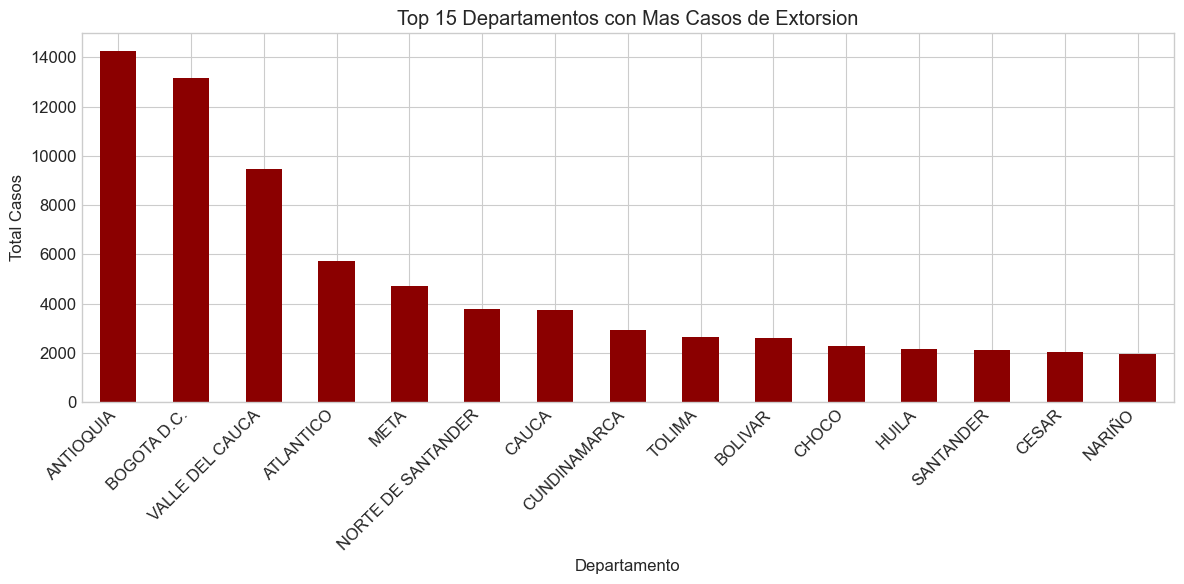

In [33]:
print("="*80)
print("VISUALIZACION GEOGRAFICA".center(80))
print("="*80)

# Top departamentos por extorsion
print("\nTOP 10 DEPARTAMENTOS CON MAS EXTORSIONES")
print("-"*50)

extorsion_depto = datos.groupby('dpto_nombre')[target].sum().sort_values(ascending=False)
print(extorsion_depto.head(10))

# Visualizar
plt.figure(figsize=(12, 6))
extorsion_depto.head(15).plot(kind='bar', color='darkred')
plt.title('Top 15 Departamentos con Mas Casos de Extorsion')
plt.xlabel('Departamento')
plt.ylabel('Total Casos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
save_figure('top_departamentos')
plt.show()

---
## 14. Conclusiones y Resumen Final

In [35]:
print("="*80)
print("RESUMEN Y CONCLUSIONES".center(80))
print("="*80)

# Generar resumen
resumen = f"""
{'='*80}
RESUMEN DE RESULTADOS DEL MODELADO PREDICTIVO DE EXTORSION EN COLOMBIA
{'='*80}

1. DATASET Y PREPARACION
{'-'*50}
   - Registros totales: {len(df):,}
   - Variables utilizadas: {len(features)}
   - Rango temporal: {df['ano'].min()} - {df['ano'].max()}
   - Division temporal:
     * Entrenamiento: {len(X_train):,} registros ({train_years[0]}-{train_years[-1]})
     * Prueba: {len(X_test):,} registros ({test_years[0]}-{test_years[-1]})

2. MODELOS EVALUADOS
{'-'*50}
"""

for name in results.keys():
    resumen += f"   - {name}: MAE={results_df.loc[name, 'MAE (Test)']:.2f}, R2={results_df.loc[name, 'R2 (Test)']:.4f}\n"

resumen += f"""
3. RESULTADOS PRINCIPALES
{'-'*50}
   - Mejor modelo (MAE): {best_mae_model}
     * MAE: {results_df.loc[best_mae_model, 'MAE (Test)']:.2f}
   - Mejor modelo (R2): {best_r2_model}
     * R2: {results_df.loc[best_r2_model, 'R2 (Test)']:.4f}

4. PRECISION DEL MEJOR MODELO
{'-'*50}
"""

for threshold, precision in precision_by_threshold.items():
    resumen += f"   - Predicciones con error <= {threshold} casos: {precision:.2f}%\n"

resumen += f"""
5. ARCHIVOS GENERADOS
{'-'*50}
   Directorio: {output_dir}/
"""

# Listar archivos generados
for filename in sorted(os.listdir(output_dir)):
    resumen += f"   - {filename}\n"

resumen += f"""
{'='*80}
Generado: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
{'='*80}
"""

print(resumen)

# Guardar resumen
with open(f'{output_dir}/resumen_resultados.txt', 'w', encoding='utf-8') as f:
    f.write(resumen)

print(f"\nResumen guardado: {output_dir}/resumen_resultados.txt")

print("\n" + "="*80)
print("PROCESO COMPLETO FINALIZADO CON EXITO".center(80))
print("="*80)

                             RESUMEN Y CONCLUSIONES                             

RESUMEN DE RESULTADOS DEL MODELADO PREDICTIVO DE EXTORSION EN COLOMBIA

1. DATASET Y PREPARACION
--------------------------------------------------
   - Registros totales: 7,235
   - Variables utilizadas: 11
   - Rango temporal: 2016 - 2025
   - Division temporal:
     * Entrenamiento: 5,651 registros (2016-2023)
     * Prueba: 1,584 registros (2024-2025)

2. MODELOS EVALUADOS
--------------------------------------------------
   - Linear Regression: MAE=9.63, R2=0.7685
   - Random Forest: MAE=7.56, R2=0.6085
   - Gradient Boosting: MAE=7.70, R2=0.6222
   - XGBoost: MAE=8.43, R2=0.3208

3. RESULTADOS PRINCIPALES
--------------------------------------------------
   - Mejor modelo (MAE): Random Forest
     * MAE: 7.56
   - Mejor modelo (R2): Linear Regression
     * R2: 0.7685

4. PRECISION DEL MEJOR MODELO
--------------------------------------------------
   - Predicciones con error <= 1 casos: 7.51%
   